In [2]:
import numpy as np
import pandas as pd 
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.shape

(1030, 9)

In [5]:
df.isnull().mean()

Cement                0.0
Blast Furnace Slag    0.0
Fly Ash               0.0
Water                 0.0
Superplasticizer      0.0
Coarse Aggregate      0.0
Fine Aggregate        0.0
Age                   0.0
Strength              0.0
dtype: float64

In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
X = df.drop(columns=['Strength'])
y= df.iloc[: , -1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
# Applying linear regression
lr = LinearRegression()

lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.6275531792314848

In [12]:
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.4609940491662864)

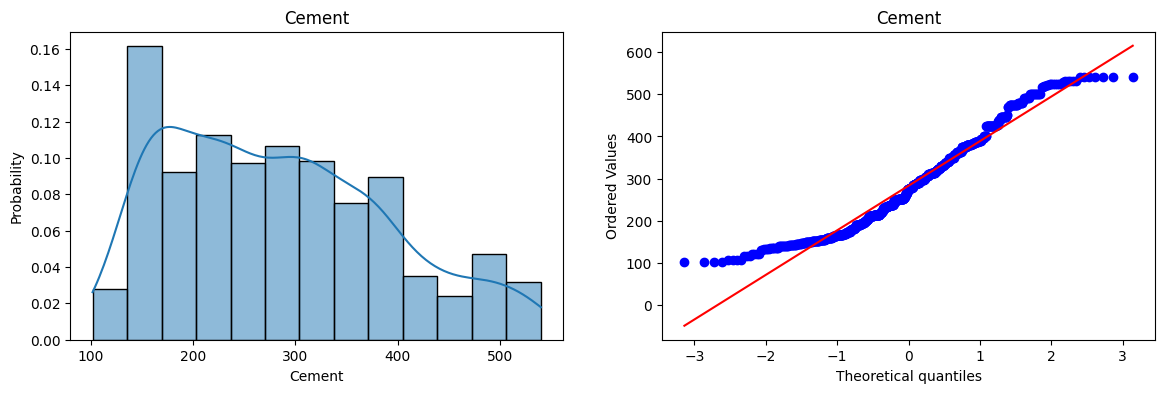

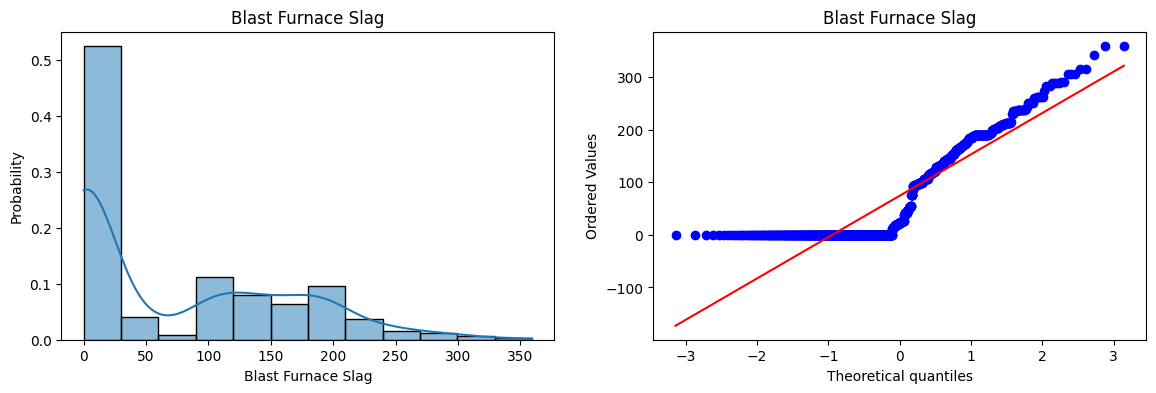

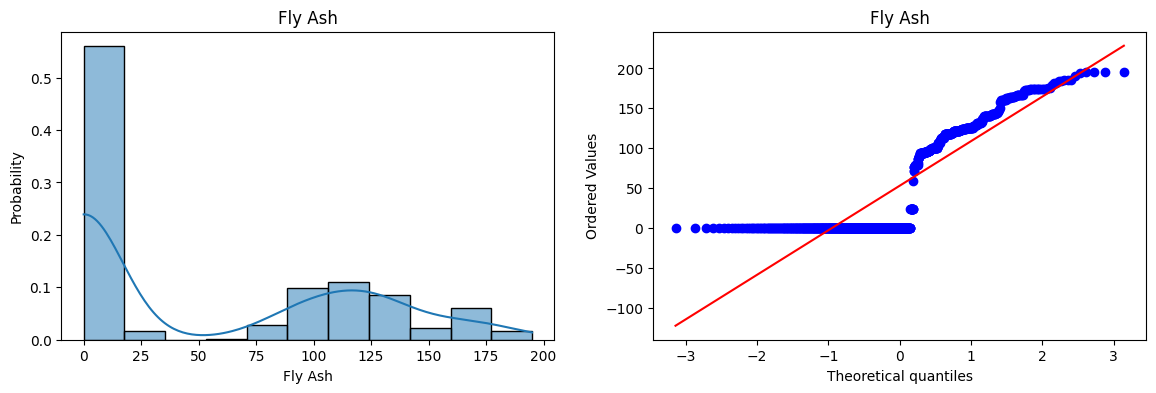

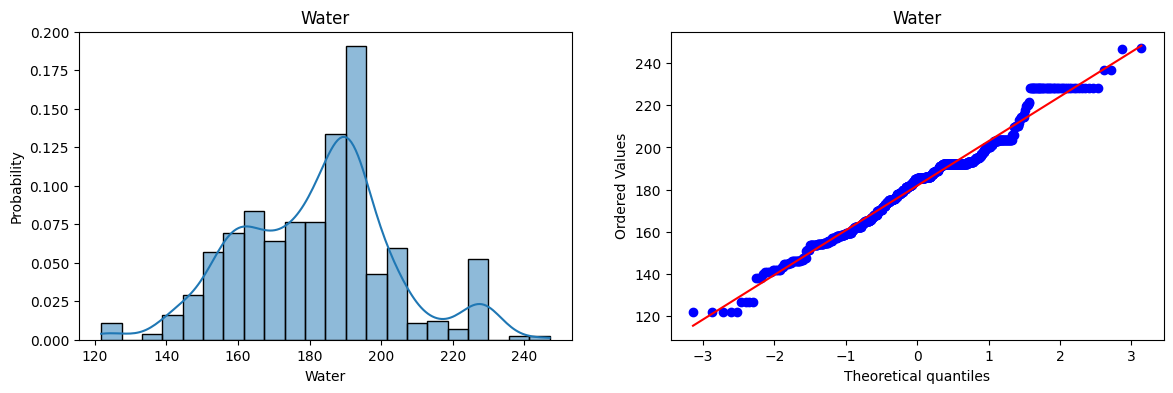

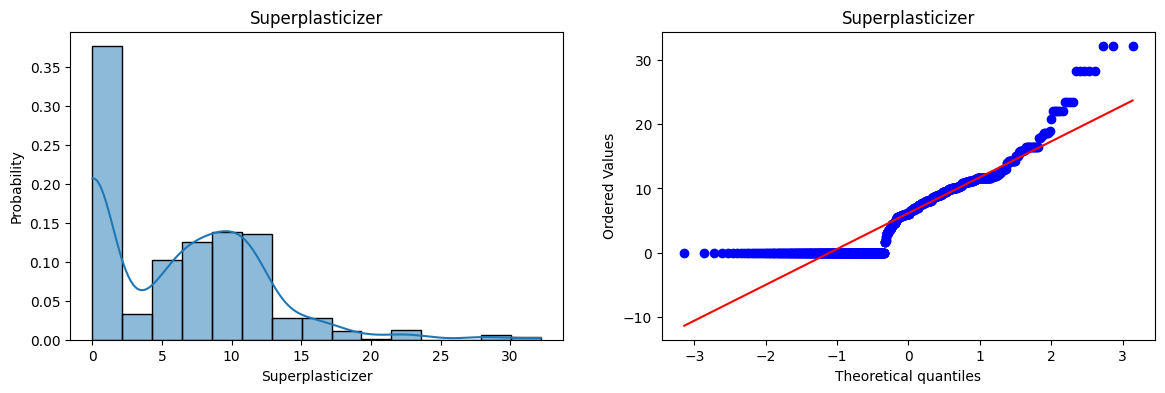

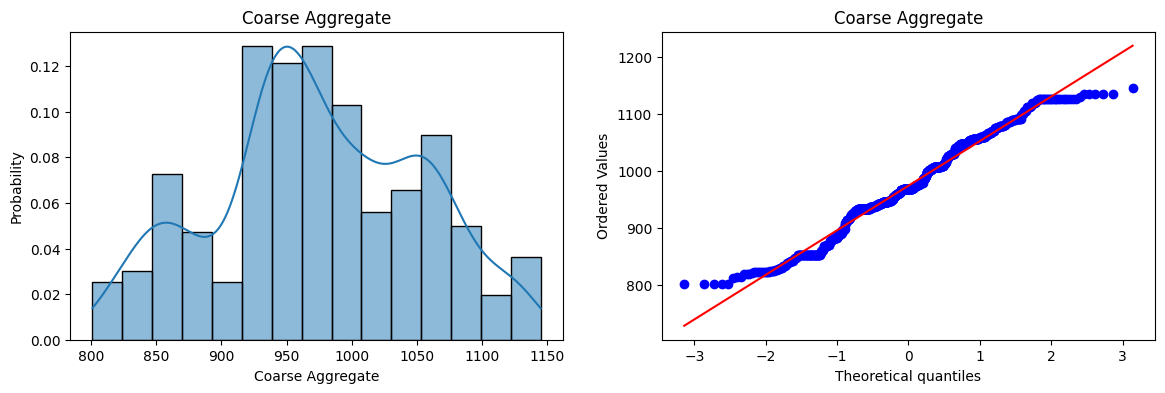

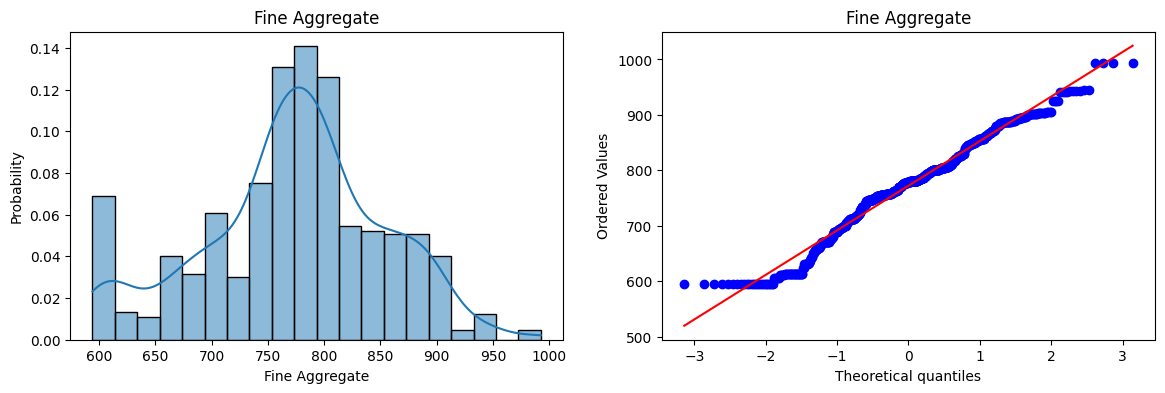

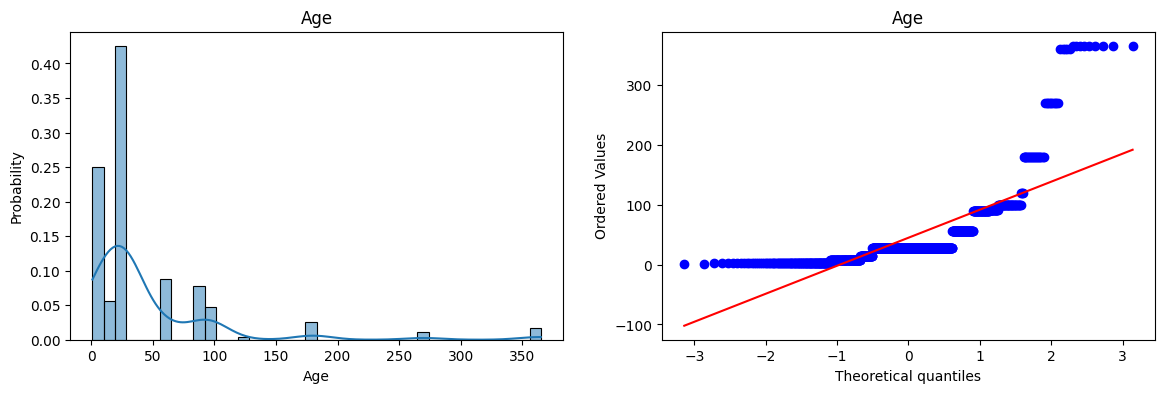

In [13]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True,stat='probability')
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [16]:
# applying box cox transform
pt = PowerTransformer(method='box-cox')

X_train_trasformed = pt.fit_transform(X_train + 0.000001)
X_test_trasformed = pt.transform(X_test + 0.000001)

pd.DataFrame({'cols': X_train.columns, 'box_cox_lambas': pt.lambdas_})

,cols,box_cox_lambas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [18]:
lr = LinearRegression()
lr.fit(X_train_trasformed,y_train)
y_pred2 = lr.predict(X_test_trasformed)
r2_score(y_test,y_pred2)

0.8047825008078886

In [24]:
pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.00000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6654921097182622)

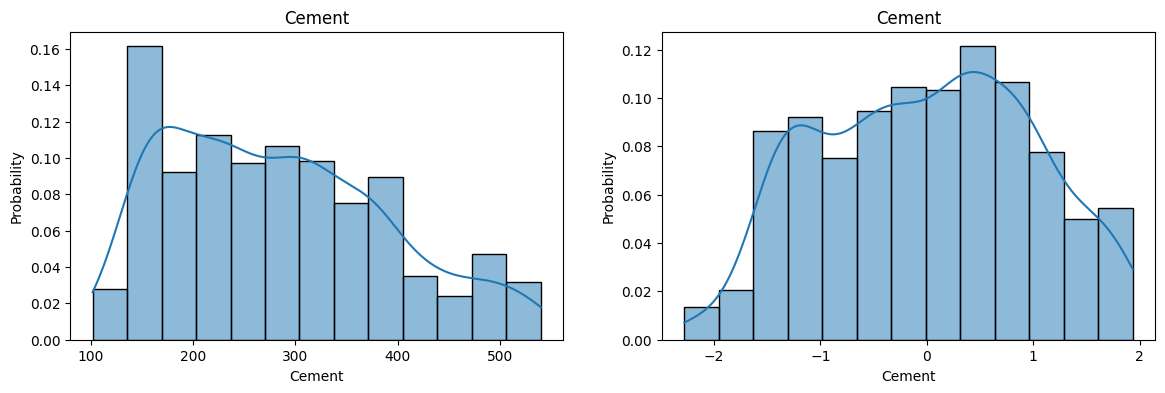

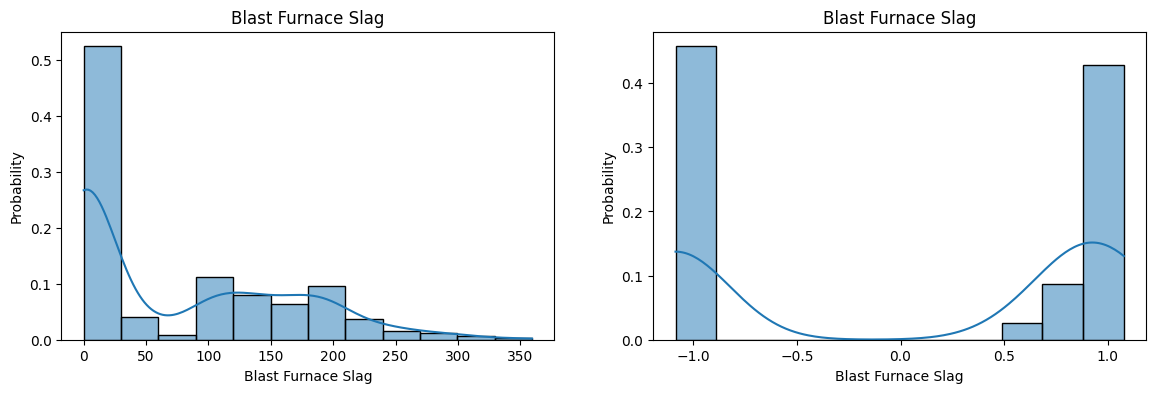

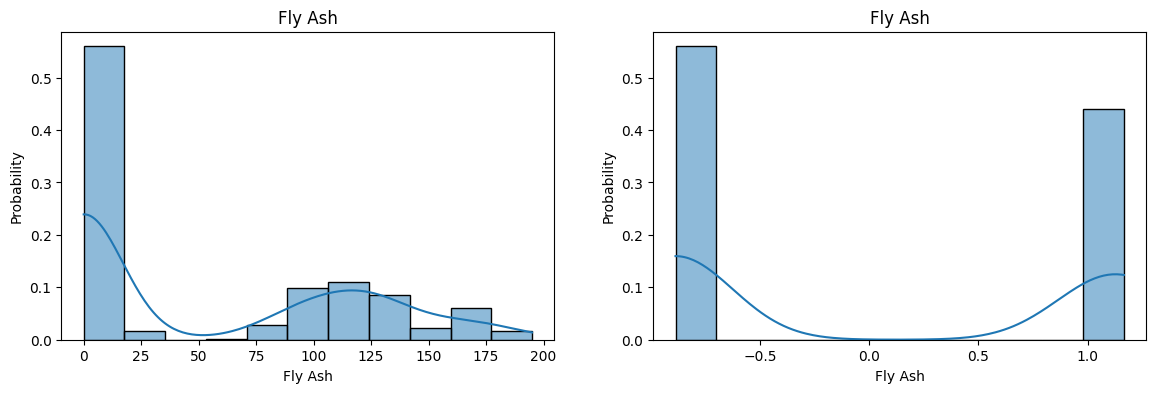

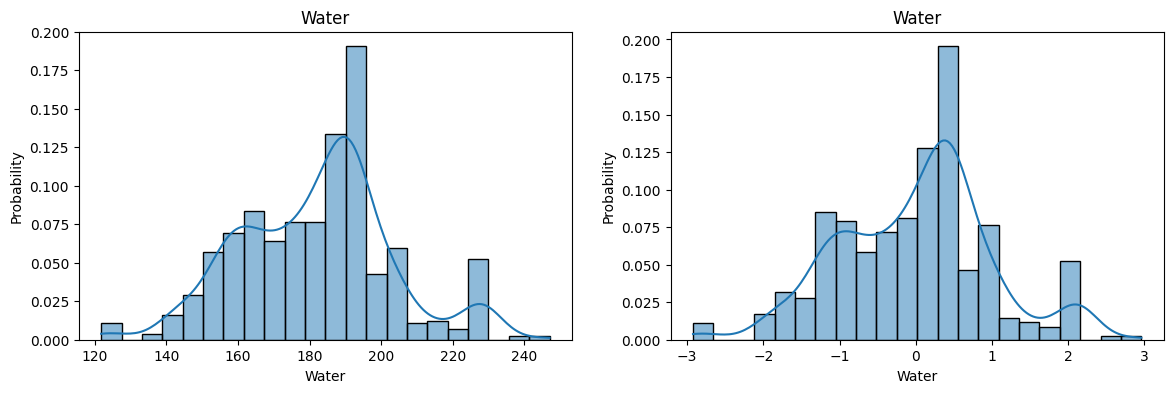

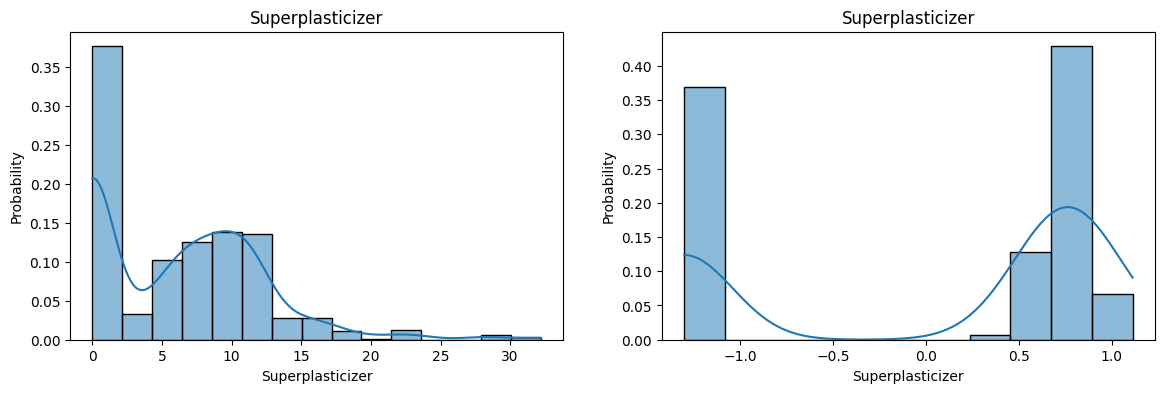

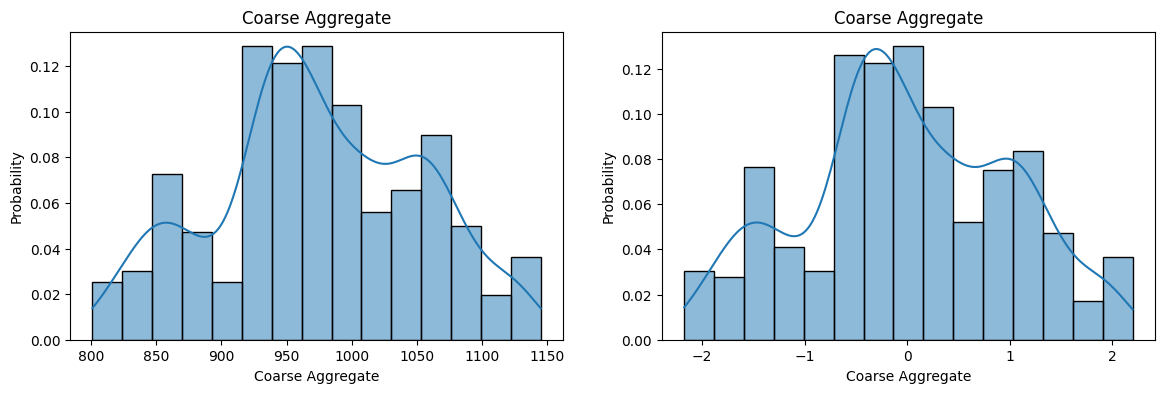

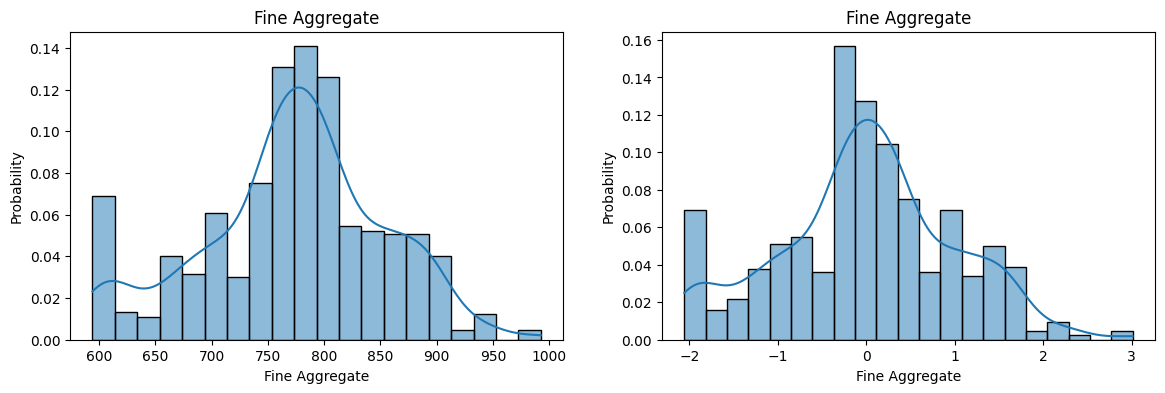

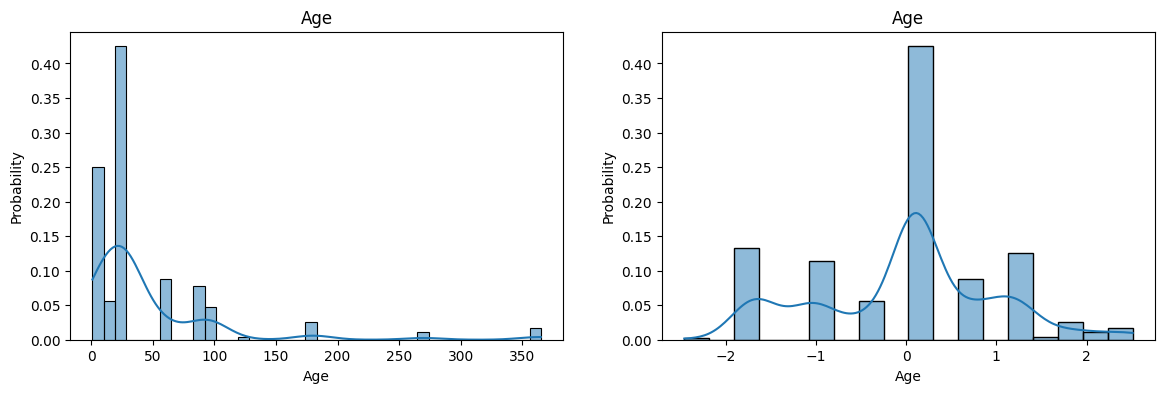

In [29]:
X_train_trasformed = pd.DataFrame(X_train_trasformed,columns=X_train.columns)
for col in X_train_trasformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True,stat='probability')
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_trasformed[col],kde=True,stat='probability')
    plt.title(col)

    plt.show()

### YO-Johnson

In [30]:
pt1 = PowerTransformer()

X_train_trasformed2 = pt1.fit_transform(X_train)
X_test_trasformed2 = pt1.transform(X_test)

lr =LinearRegression()
lr.fit(X_train_trasformed2,y_train)

Y_pred3 = lr.predict(X_test_trasformed2)
print(r2_score(y_test,Y_pred3))

pd.DataFrame({'cols': X_train.columns,'Yeo_johnson_lambdas': pt1.lambdas_})

0.8161906511066098


,cols,Yeo_johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [31]:
pt = PowerTransformer()
X_test_trasformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_test_trasformed2,y,scoring='r2'))

np.float64(0.6834625126992443)

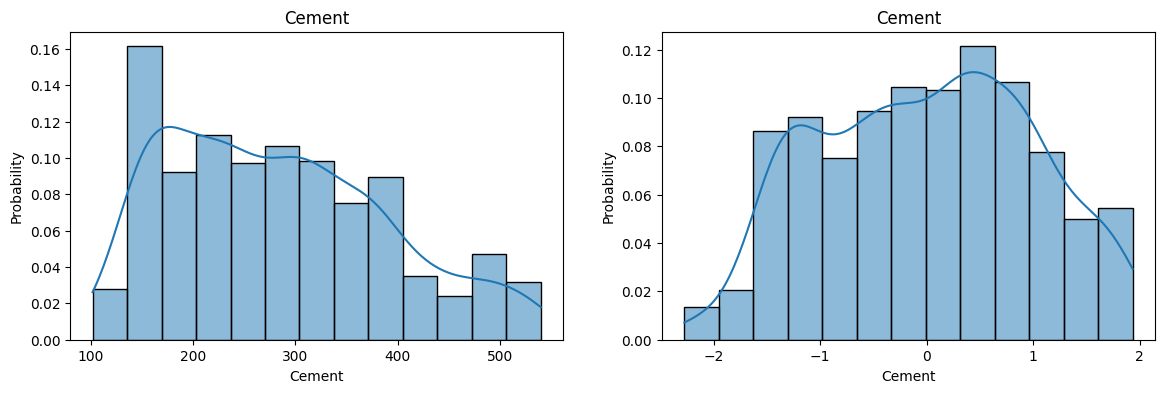

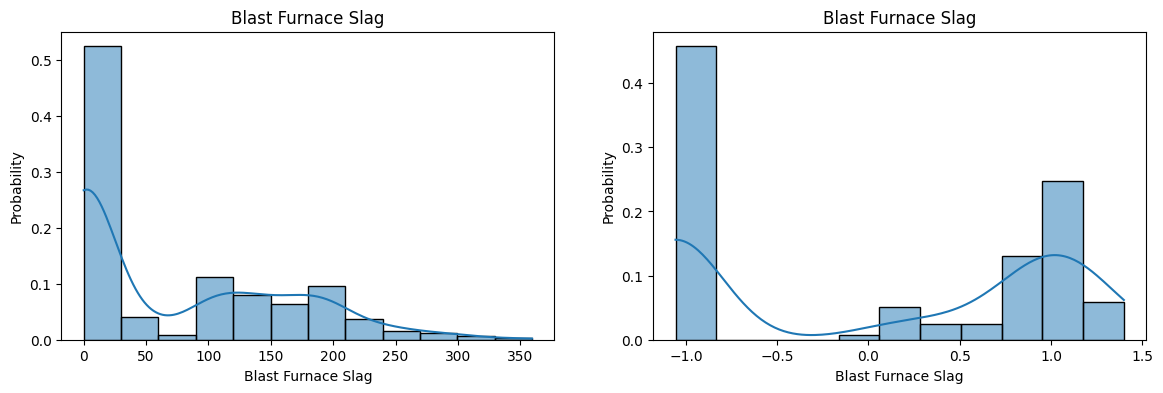

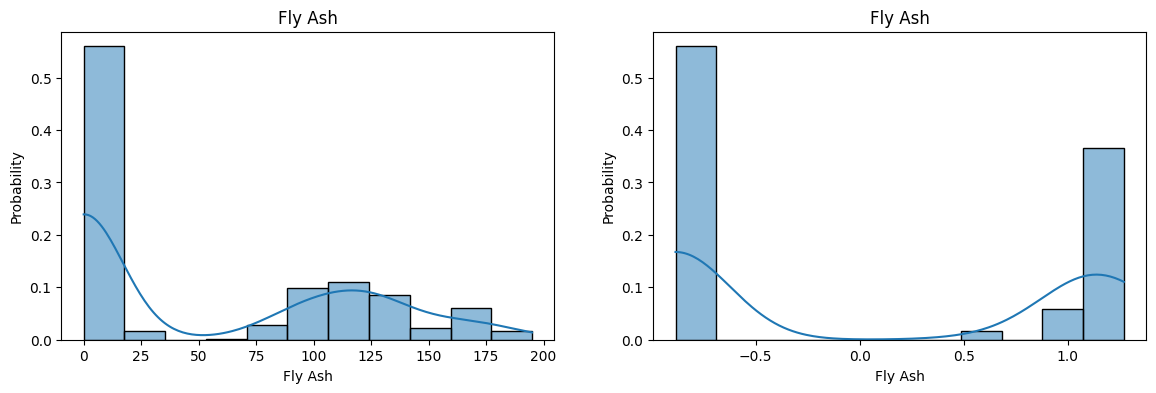

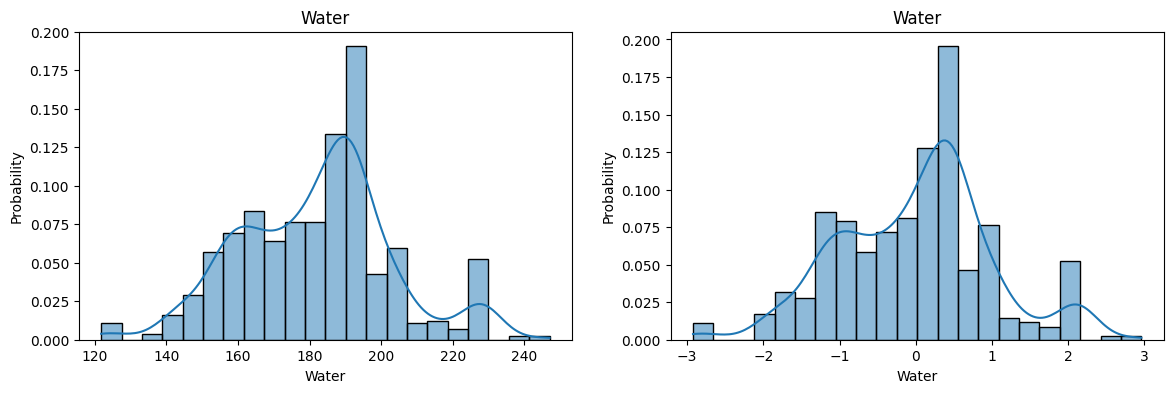

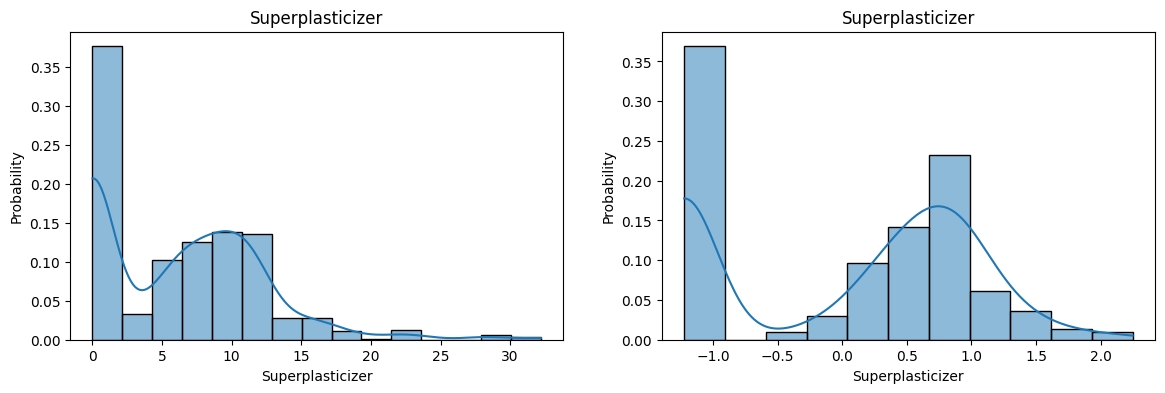

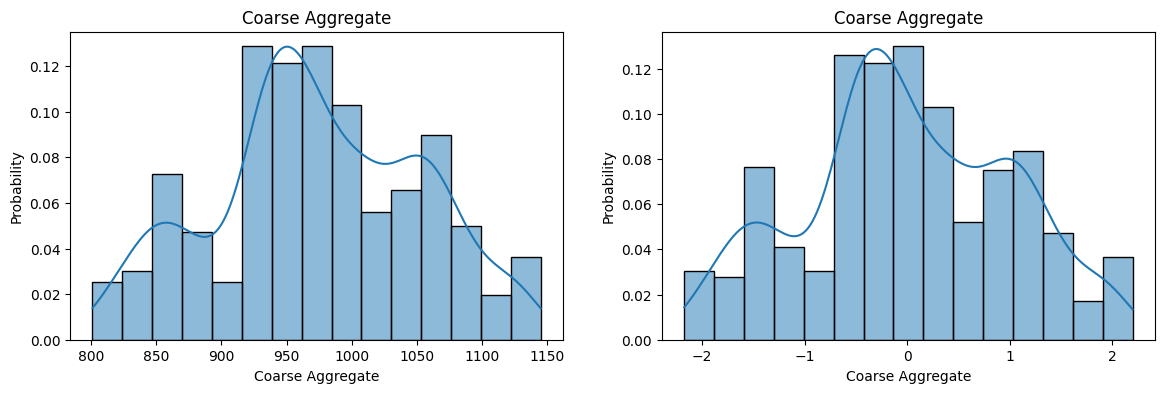

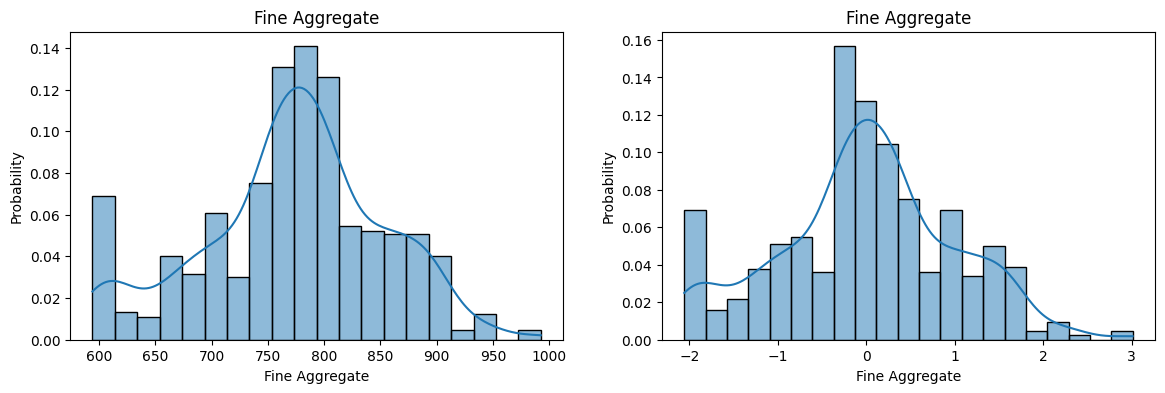

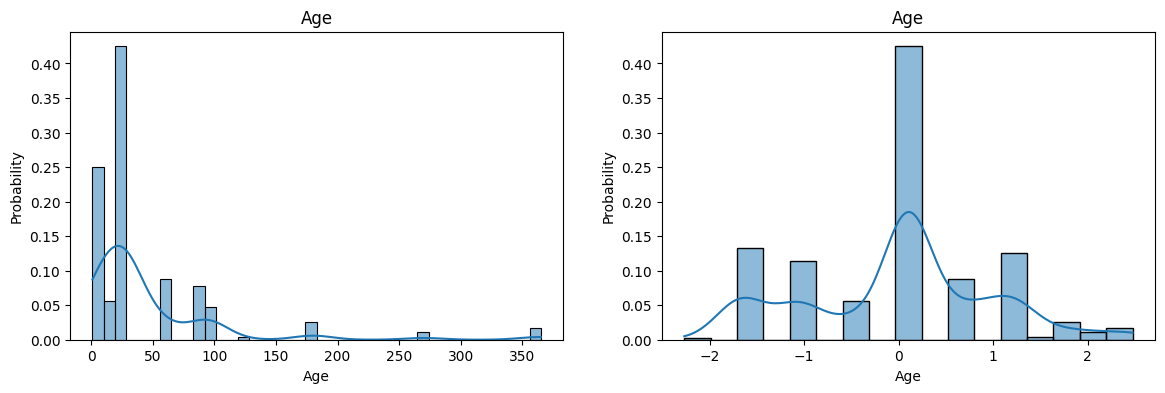

In [32]:
X_train_transformed2 =pd.DataFrame(X_train_trasformed2,columns=X_train.columns)
for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True,stat='probability')
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed2[col],kde=True,stat='probability')
    plt.title(col)

    plt.show()

In [33]:
pd.DataFrame({'cols':X_train.columns,'box_cos_lambadas': pt.lambdas_,'you_johnson_lambadas': pt1.lambdas_})

,cols,box_cos_lambadas,you_johnson_lambadas
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830764,1.783100
7,Age,0.001771,0.019885
